simulation steps:

- construct layout of pond
- determine mic locations
- create fake sound source
- create received data for microphones (tdoas, bearing, etc)
- localize
- introduce error
    - +/- error in time it takes for sound to reach each mic
    - +/-0.0001 error in mic GPS location 
    - change temperature/incorporate temperature into propogation calculations
    - simultaneous bird calls

localization steps:
- set mic and source locations
- distances = mic - source
- abs distance = sqrt(distances_x^2 + distances_y^2 + distances_z^2)
- time delay = abs_distance/c where c=343 m/s
- construct tdoa matrix where each row is [x0 - xn, y0 - yn, z0 - zn, abs_dist0n]
- wn0 = 0.5*(dn0**2 - xn**2 + x0**3 - yn**2 + y0**2 - zn**2 + z0**2) = 0.5(dn0^2 + x0^2 + y0^2 + z0^2 - xn^2 - yn^2 - zn^2)
- solve matrix for xs, ys, zs, Ds0

In [17]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np

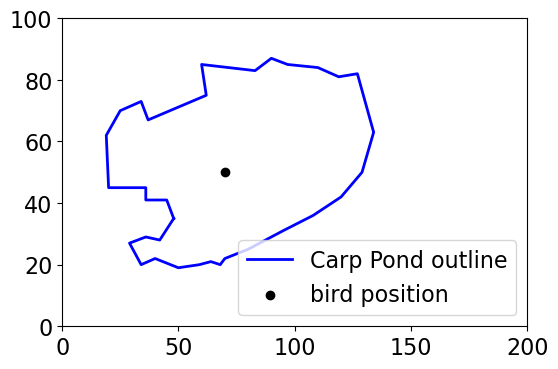

In [18]:
### construct pond layout, units are all in meters (CREDIT: AMEENA MAJEED)
CARP_POND_OUTLINE = np.array([[48, 35], [45, 41], [36, 41], [36, 45], [20, 45], [19, 62], [25, 70], [34, 73], [37, 67], 
                 [62, 75], [60, 85], [83, 83], [90, 87], [97, 85], [110, 84], [119, 81], [127, 82], 
                 [134, 63], [129, 50], [120, 42], [108, 36], [95, 31], [80, 25], [70, 22], [68, 20], 
                 [64, 21], [59, 20], [50, 19], [40, 22], [34, 20], [29, 27], [36, 29], [42, 28], [48,35]])

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(CARP_POND_OUTLINE[:,0], CARP_POND_OUTLINE[:,1], color='b', linewidth=2, label='Carp Pond outline')
ax.scatter(70, 50, facecolor='k', edgecolor='k', label='bird position')
ax.legend(loc='lower right')
ax.set_xlim(0, 200)
ax.set_ylim(0, 100)
plt.show()

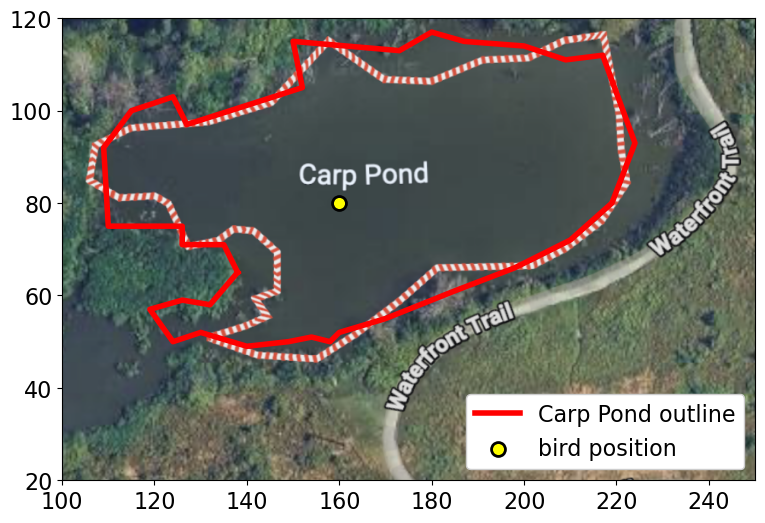

In [19]:
from pathlib import Path
import matplotlib.image as mpimg

img_path = Path("~/Downloads/carp_pond_google_aerial.png").expanduser()
pond_img = mpimg.imread(img_path)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.imshow(pond_img, extent=[0, 380, 0, 260], origin="upper", alpha=1)
ax.plot(CARP_POND_OUTLINE[:, 0]+90, CARP_POND_OUTLINE[:, 1]+30, color="r", linewidth=4, label="Carp Pond outline",)
ax.scatter(160, 80, s=100, facecolor="yellow", edgecolor="k", linewidth=2, label="bird position")

ax.legend(loc="lower right", framealpha=1)
ax.set_xlim(100, 250)
ax.set_ylim(20, 120)
ax.set_aspect("equal")
plt.show()

In [20]:
TIME_DURATION = 0.5 # 1s (in seconds)
CHIRP_LENGTH = 0.1 # 100ms (in seconds)
CHIRP_FREQ_LOWERBOUND = 1e3 # 1kHz (in Hz)
CHIRP_FREQ_UPPERBOUND = 10e3 # 10kHz (in Hz)
FS = 48000

t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
raw_signal = sp.signal.chirp(t, f0=CHIRP_FREQ_UPPERBOUND, t1=CHIRP_LENGTH, f1=CHIRP_FREQ_LOWERBOUND)
template_signal = raw_signal[:int(FS*CHIRP_LENGTH)]

window = np.hanning(template_signal.size)
template_signal_windowed = template_signal * window

time_transmitted = 0.04
signal = np.zeros(t.size)
signal[int(FS*time_transmitted):int(FS*(time_transmitted+CHIRP_LENGTH))] += template_signal_windowed
signal_duration = TIME_DURATION/2

/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)


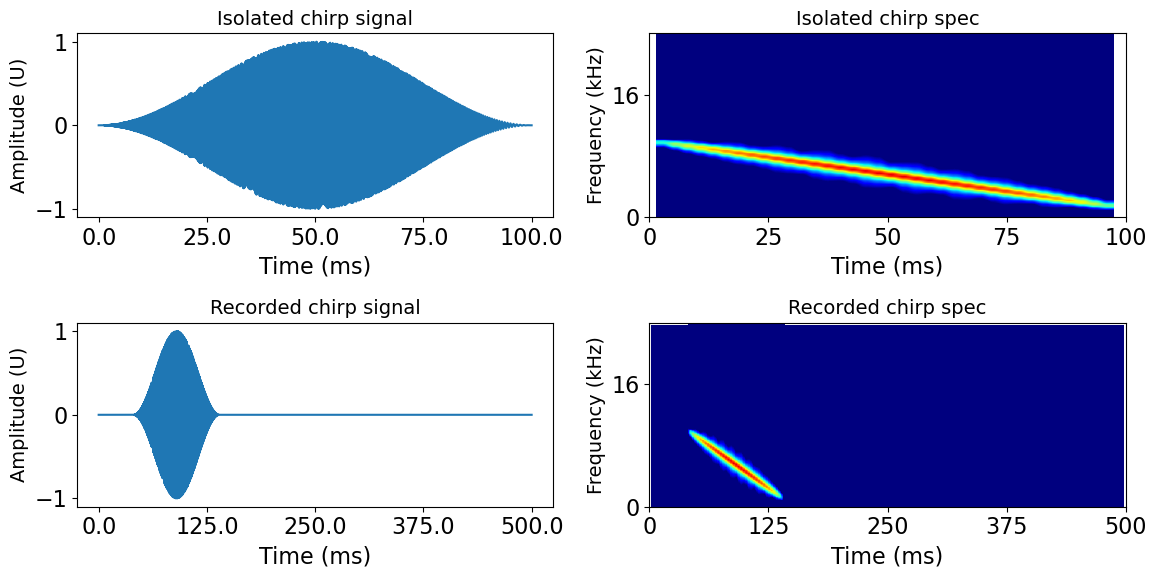

In [21]:
spec_features = dict()
spec_features['NFFT'] = 256 # When segments are short, NFFT should also be small (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = -80
spec_features['vmax'] = 0

fig, ax_all = plt.subplots(2, 2, figsize=(12, 6))
plt.rcParams.update({'font.size': 14})

ax = ax_all[0,0]
ax.set_title(f"Isolated chirp signal", fontsize=14)
ax.plot(template_signal_windowed)
ax.set_xticks(np.linspace(0, (CHIRP_LENGTH*FS), 5), np.linspace(0, (CHIRP_LENGTH*1e3), 5))
ax.set_ylabel("Amplitude (U)", fontsize=14)
ax.set_xlabel("Time (ms)")

ax = ax_all[0,1]
ax.set_title(f"Isolated chirp spec", fontsize=14)
ax.specgram(template_signal_windowed+1e-6, NFFT=spec_features['NFFT'], 
                cmap='jet', vmin=spec_features['vmin'], vmax=spec_features['vmax'], mode='magnitude', scale='dB')
ax.set_yticks(np.arange(0, FS/2, 16e3) / (FS/2), np.arange(0, FS/2000, 16).astype(int))
ax.set_xticks(np.linspace(0, (CHIRP_LENGTH) * (FS/2), 5), np.linspace(0, (CHIRP_LENGTH*1e3), 5).astype(int))
ax.set_ylabel("Frequency (kHz)", fontsize=14)
ax.set_xlabel("Time (ms)")

ax = ax_all[1,0]
ax.set_title(f"Recorded chirp signal", fontsize=14)
ax.plot(signal)
ax.set_xticks(np.linspace(0, (TIME_DURATION*FS), 5), np.linspace(0, (TIME_DURATION*1e3), 5))
ax.set_ylabel("Amplitude (U)", fontsize=14)
ax.set_xlabel("Time (ms)")

ax = ax_all[1,1]
ax.set_title(f"Recorded chirp spec", fontsize=14)
ax.specgram(signal+1e-6, NFFT=spec_features['NFFT'], 
                cmap='jet', vmin=spec_features['vmin'], vmax=spec_features['vmax'], mode='magnitude', scale='dB')
ax.set_yticks(np.arange(0, FS/2, 16e3) / (FS/2), np.arange(0, FS/2000, 16).astype(int))
ax.set_xticks(np.linspace(0, (TIME_DURATION) * (FS/2), 5), np.linspace(0, (TIME_DURATION*1e3), 5).astype(int))
ax.set_ylabel("Frequency (kHz)", fontsize=14)
ax.set_xlabel("Time (ms)")

fig.tight_layout()
plt.show()

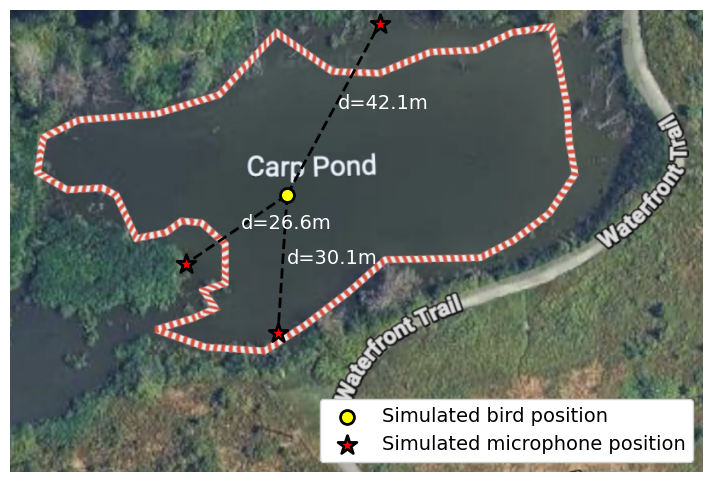

In [22]:
from pathlib import Path
import matplotlib.image as mpimg

img_path = Path("~/Downloads/carp_pond_google_aerial.png").expanduser()
pond_img = mpimg.imread(img_path)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.imshow(pond_img, extent=[0, 380, 0, 260], origin="upper", alpha=1)
# ax.plot(CARP_POND_OUTLINE[:, 0]+90, CARP_POND_OUTLINE[:, 1]+30, color="r", linewidth=4, label="Carp Pond outline")

bird_pos = (160, 80)
ax.scatter(bird_pos[0], bird_pos[1], s=100, facecolor="yellow", edgecolor="k", linewidth=2, label="Simulated bird position", zorder=2)
ax.scatter(CARP_POND_OUTLINE[0][0] + 90, CARP_POND_OUTLINE[0][1] + 30, s=200, 
           marker='*', facecolor="red", edgecolor="k", linewidth=2, label="Simulated microphone position", zorder=2)

distance_to_mics = []
for i, outline_pos in enumerate(CARP_POND_OUTLINE[::12]):
    recorder_pos = (outline_pos[0] + 90, outline_pos[1] + 30)
    if i > 0:
        ax.scatter(recorder_pos[0],recorder_pos[1], s=200, marker='*', facecolor="red", edgecolor="k", linewidth=2, zorder=2)
    ax.plot([bird_pos[0], recorder_pos[0]], [bird_pos[1], recorder_pos[1]], color='k', linewidth=2, linestyle='dashed', zorder=1)
    distance_to_mic = (np.sqrt((bird_pos[0]-recorder_pos[0])**2 + (bird_pos[1]-recorder_pos[1])**2))
    distance_to_mics += [distance_to_mic]
    ax.text(1 + ((bird_pos[0] + recorder_pos[0]) / 2), (bird_pos[1] + recorder_pos[1]) / 2, s=f'd={distance_to_mic:.1f}m', color='w')

ax.legend(loc="lower right", framealpha=1)
ax.set_xlim(100, 250)
ax.set_ylim(20, 120)
ax.set_aspect("equal")
ax.axis('off')
plt.show()

In [7]:
def attenuation_downwind_linear_regression(distance_in_meters):
    return (distance_in_meters + 84.72) / 3.77

def attenuation_nowind_linear_regression(distance_in_meters):
    return (distance_in_meters + 66.69) / 3.39

def attenuation_upwind_linear_regression(distance_in_meters):
    return (distance_in_meters + 33.13) / 2.28

In [8]:
dist_from_recorder = 60
attenuation_for_upwind = attenuation_upwind_linear_regression(dist_from_recorder)
attenuation_for_nowind = attenuation_nowind_linear_regression(dist_from_recorder)
attenuation_for_downwind = attenuation_downwind_linear_regression(dist_from_recorder)

(attenuation_for_upwind, attenuation_for_nowind, attenuation_for_downwind)

(40.84649122807018, 37.3716814159292, 38.38726790450929)

In [9]:
dist_from_recorder = 120
attenuation_for_upwind = attenuation_upwind_linear_regression(dist_from_recorder)
attenuation_for_nowind = attenuation_nowind_linear_regression(dist_from_recorder)
attenuation_for_downwind = attenuation_downwind_linear_regression(dist_from_recorder)

(attenuation_for_upwind, attenuation_for_nowind, attenuation_for_downwind)

(67.16228070175438, 55.070796460176986, 54.30238726790451)

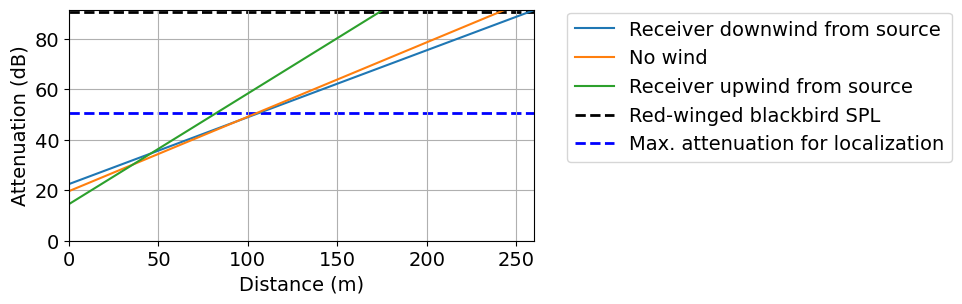

In [10]:
begin_dist = 0
end_dist = 260
distances_from_recorder = np.arange(begin_dist, end_dist)
attenuation_for_upwind = attenuation_upwind_linear_regression(distances_from_recorder)
attenuation_for_nowind = attenuation_nowind_linear_regression(distances_from_recorder)
attenuation_for_downwind = attenuation_downwind_linear_regression(distances_from_recorder)

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(attenuation_for_downwind, label='Receiver downwind from source', zorder=2)
ax.plot(attenuation_for_nowind, label='No wind', zorder=2)
ax.plot(attenuation_for_upwind, label='Receiver upwind from source', zorder=2)

REDWINGED_BLACKBIRD_SPL = 90.8 #dB SPL
ax.axhline(y=REDWINGED_BLACKBIRD_SPL, linestyle='dashed', color='k', linewidth=2, zorder=1, label='Red-winged blackbird SPL')

LOCALIZATION_THRESHOLD = 40
ax.axhline(y=REDWINGED_BLACKBIRD_SPL - LOCALIZATION_THRESHOLD, linestyle='dashed', color='blue', linewidth=2, zorder=1, label='Max. attenuation for localization')

ax.set_ylabel("Attenuation (dB)")
ax.set_xlabel('Distance (m)')
ax.grid(which='both')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.03))
ax.set_xlim(begin_dist, end_dist)
ax.set_ylim(0, REDWINGED_BLACKBIRD_SPL+0.8)

plt.show()

In [11]:
time_traveled_to_mics = (np.array(distance_to_mics) / 343)
time_traveled_to_mics

array([0.07762989, 0.1226224 , 0.0876577 ])

In [12]:
time_transmitted = 0.04
time_received = time_traveled_to_mics + time_transmitted

signal_at_mics = []
for time_received_at_mic in time_received:
    signal_at_mic = np.zeros(t.size)+1e-6
    signal_at_mic[int(FS*time_received_at_mic):int(FS*(time_received_at_mic+CHIRP_LENGTH))] += template_signal_windowed
    signal_at_mics += [signal_at_mic]

In [13]:
TIME_DURATION*(FS/2)

12000.0

/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)
/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)
/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)


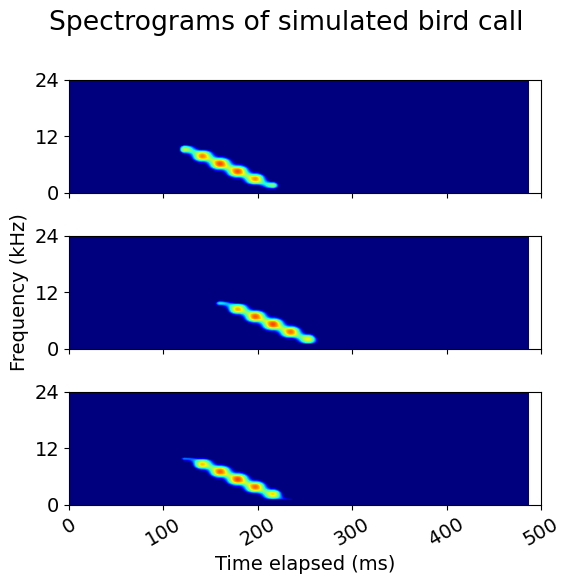

In [14]:
fig, ax_all = plt.subplots(len(signal_at_mics), 1, figsize=(6, 6), sharex = True)
plt.rcParams.update({'font.size': 16})
fig.suptitle(f'Spectrograms of simulated bird call')

for i, signal_at_mic in enumerate(signal_at_mics):
    ax = ax_all[i]

    vmax = 0
    vmin = -100

    spec_features = dict()
    spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
    spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
    spec_features['vmin'] = vmin
    spec_features['vmax'] = vmax

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    _, _, _, im = ax.specgram(signal_at_mic, NFFT=nfft, Fs=FS, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    ax.set_yticks(ticks=np.linspace(0, FS/2, 3), labels=np.linspace(0, FS/2000, 3).astype('int'))
    xticks_sec = np.linspace(0, TIME_DURATION, 6)
    xtick_labels_ms = (xticks_sec * 1000).astype(int)

    ax.set_xticks(xticks_sec)
    ax.set_xticklabels(xtick_labels_ms, rotation=30)
    # fig.colorbar(im, ax=ax)
ax_all[1].set_ylabel("Frequency (kHz)")
ax_all[2].set_xlabel("Time elapsed (ms)")
fig.tight_layout()
plt.show()